In [85]:
%reload_ext autoreload
%autoreload 2

import sys
import os

cwd = os.getcwd()
parent_dir = os.path.abspath(os.path.join(cwd, '..'))
sys.path.append(parent_dir)

import c2qa
import numpy as np
import matplotlib.pyplot as plt
from qiskit import QuantumRegister, ClassicalRegister
from qiskit.circuit.library import RGate
from qiskit.converters import circuit_to_gate
from qutip import *
from qiskit.circuit import Parameter
from qiskit.circuit.library import UnitaryGate
from custom_gates import shors,state_generation
from qiskit.visualization import plot_histogram
from scipy.stats.contingency import margins
from qiskit.quantum_info import partial_trace

In [104]:
cutoff = 2**6
qmr1 = c2qa.QumodeRegister(num_qumodes=3, num_qubits_per_qumode=int(np.ceil(np.log2(cutoff))),name = 'qumode')
qbr = QuantumRegister(1)
cr = ClassicalRegister(1)

## Q displacement by +1

In [3]:
circuit = c2qa.CVCircuit(qmr1,qbr,cr)
circuit.cv_sq(-np.log(0.252),qmr1[0])  # qumode 0 in squeezed vaccum at x=0

Q_displace = shors.Q_displacement_plus1(cutoff)
gate1 =UnitaryGate(Q_displace.full(), label='Q+1')
circuit.append(gate1, qmr1[0])
circuit.append(gate1, qmr1[0])

circuit.barrier()

# circuit.measure(qmr1[0],cr)
stateop, result, _ = c2qa.util.simulate(circuit,shots = 128)
# circuit.draw('mpl')

In [4]:
rho_qumode_0 = shors.get_reduced_qumode_density_matrix(stateop, qumode_index=0, num_qumodes=3, cutoff=cutoff)

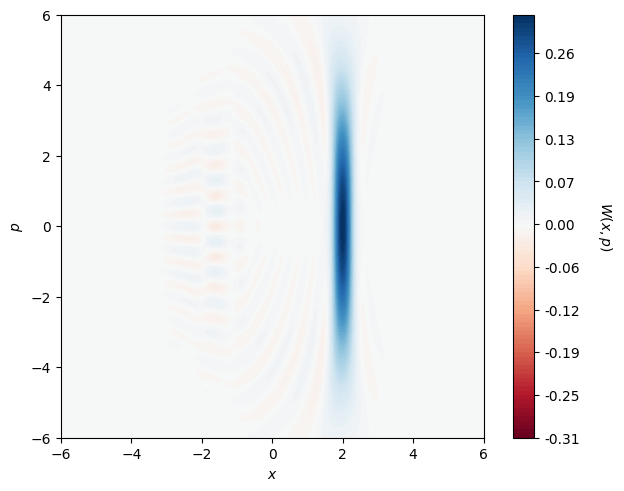

In [5]:
circuit1 = c2qa.CVCircuit(qmr1)

fig = c2qa.wigner.plot_wigner(circuit1, rho_qumode_0)

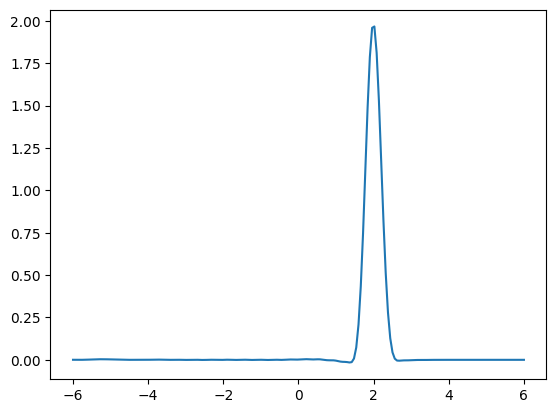

In [6]:
x_dist,xaxis = shors.position_plotting(rho_qumode_0,cutoff)

display(plt.plot(xaxis,x_dist))

## Q displacement -1

In [7]:
circuit = c2qa.CVCircuit(qmr1,qbr,cr)
circuit.cv_sq(-np.log(0.252),qmr1[0])  # qumode 0 in squeezed vaccum at x=0

Q_displace = shors.Q_displacement_minus1(cutoff)
gate1 =UnitaryGate(Q_displace.full(), label='Q11')
circuit.append(gate1, qmr1[0])

circuit.barrier()

# circuit.measure(qmr1[0],cr)
stateop, result, _ = c2qa.util.simulate(circuit,shots = 128)

In [8]:
rho_qumode_0 = shors.get_reduced_qumode_density_matrix(stateop, qumode_index=0, num_qumodes=3, cutoff=cutoff)

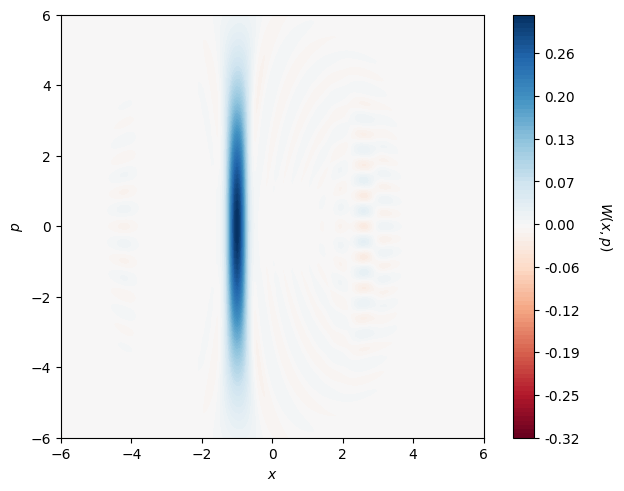

In [9]:
circuit1 = c2qa.CVCircuit(qmr1)

fig = c2qa.wigner.plot_wigner(circuit1, rho_qumode_0)

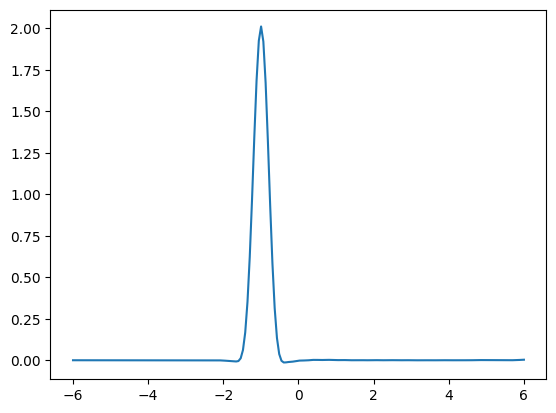

In [10]:
x_dist,xaxis = shors.position_plotting(rho_qumode_0,cutoff)

display(plt.plot(xaxis,x_dist))

## LSB Extract

In [11]:
circuit = c2qa.CVCircuit(qmr1,qbr,cr)
circuit.x(qbr[0])
circuit.cv_sq(-np.log(0.202),qmr1[0])  # qumode 0 in squeezed vaccum at x=0

Q_displace = shors.Q_displacement_plus1(cutoff)
gate1 =UnitaryGate(Q_displace.full(), label='Q+1')
circuit.append(gate1, qmr1[0])  # qumode 0 in squeezed vaccum at x=1

circuit.barrier()

LSB_extract = shors.extractLSB(cutoff)
gate1 =UnitaryGate(LSB_extract.full(), label='LSB')
circuit.append(gate1, qmr1[0]+qbr[:])

circuit.measure(qbr[0],cr)

stateop, result, _ = c2qa.util.simulate(circuit,shots = 128)

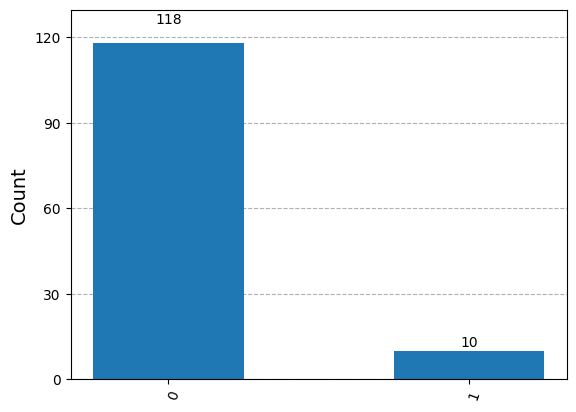

In [12]:
plot_histogram(result.get_counts())

## M_alpha

In [13]:
circuit = c2qa.CVCircuit(qmr1,qbr,cr)
circuit.cv_sq(-np.log(0.202),qmr1[0])  # qumode 0 in squeezed vaccum at x=0

Malpha = shors.multiplication(cutoff,1.5)
Q_displace = shors.Q_displacement_plus1(cutoff)
gate1 =UnitaryGate(Q_displace.full(), label='Q+1')
circuit.append(gate1, qmr1[0])
circuit.append(gate1, qmr1[0])  # qumode 0 in squeezed vaccum at x=2

gate2 =UnitaryGate(Malpha.full(), label='M2')
circuit.append(gate2, qmr1[0])  # qumode 0 in squeezed vaccum at x=4

circuit.barrier()

# circuit.measure(qmr1[0],cr)
stateop, result, _ = c2qa.util.simulate(circuit,shots = 1024)

In [14]:
rho_qumode_0 = shors.get_reduced_qumode_density_matrix(stateop, qumode_index=0, num_qumodes=3, cutoff=cutoff)

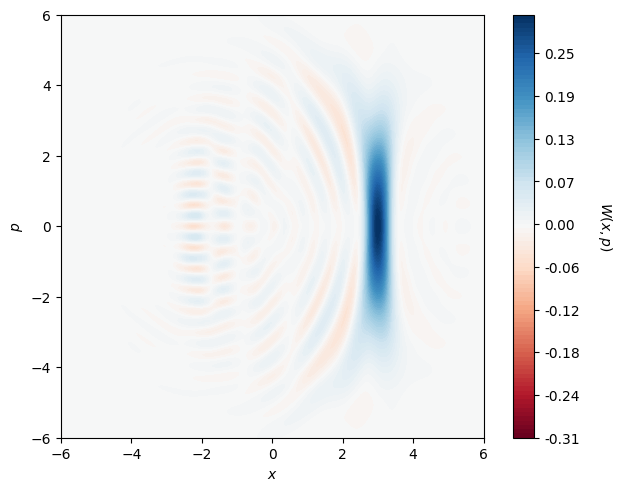

In [15]:
circuit1 = c2qa.CVCircuit(qmr1)

fig = c2qa.wigner.plot_wigner(circuit1, rho_qumode_0)

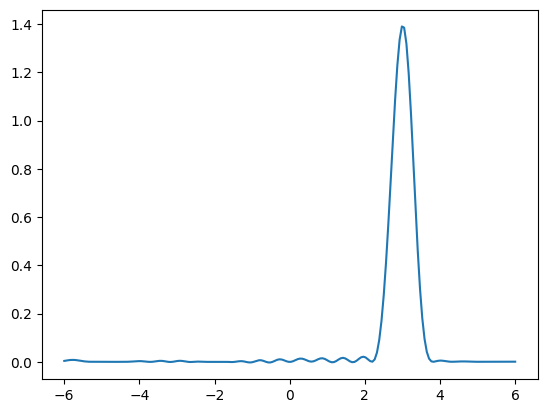

In [16]:
x_dist,xaxis = shors.position_plotting(rho_qumode_0,cutoff)

display(plt.plot(xaxis,x_dist))

## Controlled M_alpha

In [17]:
circuit = c2qa.CVCircuit(qmr1,qbr,cr)
circuit.x(qbr[0])
circuit.cv_sq(-np.log(0.202),qmr1[0])  # qumode 0 in squeezed vaccum at x=0

Q_displace = shors.Q_displacement_plus1(cutoff)
gate1 =UnitaryGate(Q_displace.full(), label='Q+1')
circuit.append(gate1, qmr1[0])  # qumode 0 in squeezed vaccum at x=1
circuit.append(gate1, qmr1[0])  # qumode 0 in squeezed vaccum at x=2

circuit.barrier()

CMalpha = shors.control_multiplication(cutoff,1)
gate1 =UnitaryGate(CMalpha.full(), label='ctrlM2')
circuit.append(gate1, qmr1[0]+qbr[:])

circuit.measure(qbr[0],cr)

stateop, result, _ = c2qa.util.simulate(circuit,shots = 128)

In [18]:
rho_qumode_0 = shors.get_reduced_qumode_density_matrix(stateop, qumode_index=0, num_qumodes=3, cutoff=cutoff)

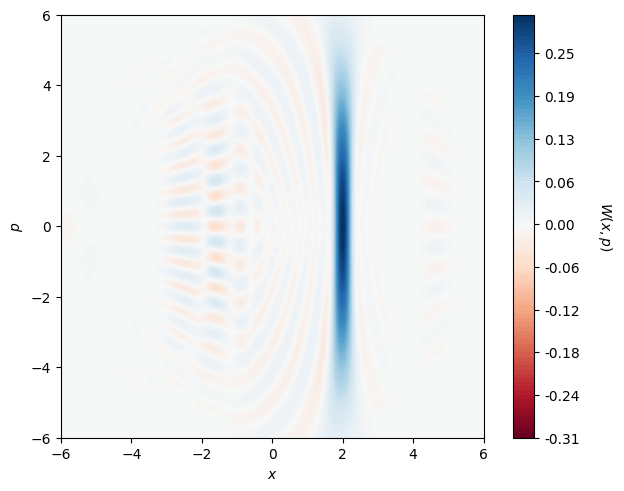

In [19]:
circuit1 = c2qa.CVCircuit(qmr1)

fig = c2qa.wigner.plot_wigner(circuit1, rho_qumode_0)

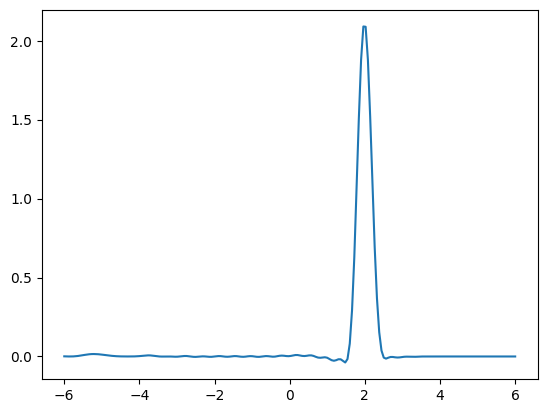

In [20]:
x_dist,xaxis = shors.position_plotting(rho_qumode_0,cutoff)

display(plt.plot(xaxis,x_dist))

## V_alpha gate

In [21]:
circuit = c2qa.CVCircuit(qmr1,qbr,cr)
circuit.cv_sq(-np.log(0.202),qmr1[0])  # qumode 0 in squeezed vaccum at x=0
circuit.cv_sq(-np.log(0.202),qmr1[1])  # qumode 1 in squeezed vaccum at x=0
circuit.cv_sq(-np.log(0.202),qmr1[2])  # qumode 2 in squeezed vaccum at x=0

Q_displace = shors.Q_displacement_plus1(cutoff)
gate1 =UnitaryGate(Q_displace.full(), label='Q+1')

circuit.append(gate1, qmr1[0])  # qumode 0 in squeezed vaccum at x=1
circuit.append(gate1, qmr1[0])  # qumode 0 in squeezed vaccum at x=2
circuit.append(gate1, qmr1[0])  # qumode 0 in squeezed vaccum at x=3

circuit.append(gate1, qmr1[1])  # qumode 1 in squeezed vaccum at x=1
circuit.append(gate1, qmr1[1])  # qumode 1 in squeezed vaccum at x=2

circuit.append(gate1, qmr1[2])  # qumode 2 in squeezed vaccum at x=1

circuit.barrier()

circuit = shors.V_alpha(cutoff,circuit,qmr1,qbr,2)

circuit.measure(qbr[0],cr)

stateop, result, _ = c2qa.util.simulate(circuit,shots = 1024)

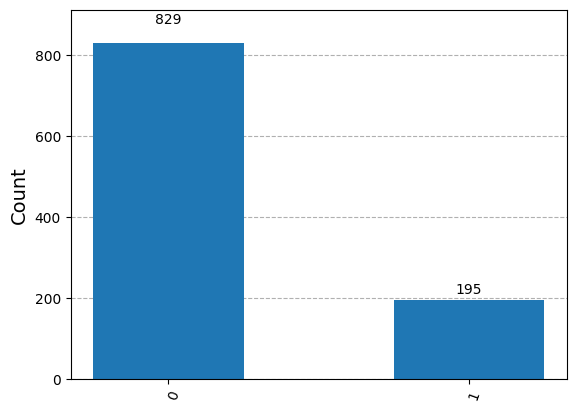

In [22]:
plot_histogram(result.get_counts())

In [23]:
rho_qumode_2 = shors.get_reduced_qumode_density_matrix(stateop, qumode_index=2, num_qumodes=3, cutoff=cutoff)
rho_qumode_1 = shors.get_reduced_qumode_density_matrix(stateop, qumode_index=1, num_qumodes=3, cutoff=cutoff)
rho_qumode_0 = shors.get_reduced_qumode_density_matrix(stateop, qumode_index=0, num_qumodes=3, cutoff=cutoff)

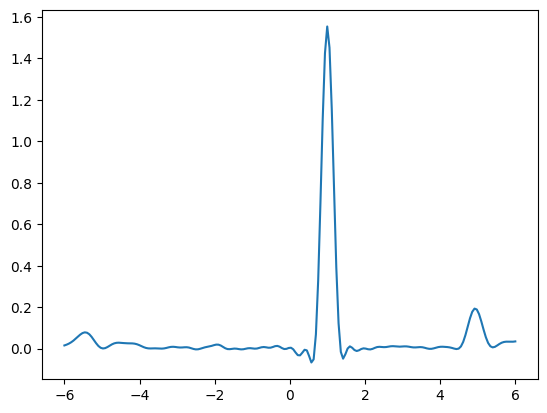

In [24]:
x_dist,xaxis = shors.position_plotting(rho_qumode_0,cutoff)
display(plt.plot(xaxis,x_dist))

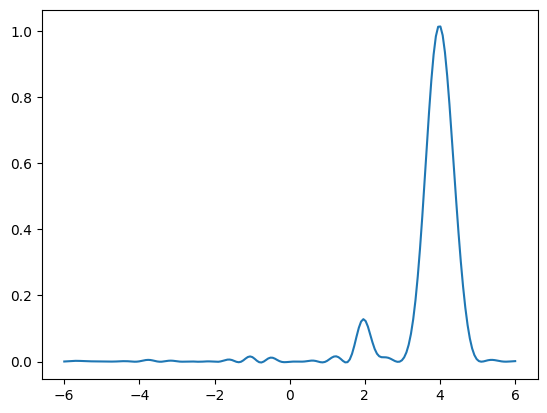

In [25]:
x_dist,xaxis = shors.position_plotting(rho_qumode_1,cutoff)
display(plt.plot(xaxis,x_dist))

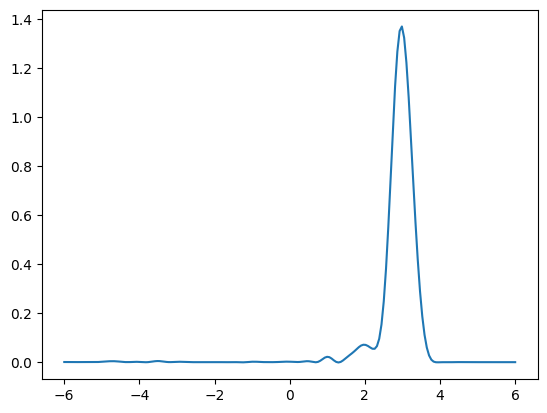

In [26]:
x_dist,xaxis = shors.position_plotting(rho_qumode_2,cutoff)
display(plt.plot(xaxis,x_dist))

## VaNm Gate

In [105]:
circuit = c2qa.CVCircuit(qmr1,qbr,cr)
circuit.cv_sq(-np.log(0.102),qmr1[0])  # qumode 0 in squeezed vaccum at x=0
circuit.cv_sq(-np.log(0.102),qmr1[1])  # qumode 1 in squeezed vaccum at x=0
circuit.cv_sq(-np.log(0.102),qmr1[2])  # qumode 2 in squeezed vaccum at x=0

Q_displace = shors.Q_displacement_plus1(cutoff)
gate1 =UnitaryGate(Q_displace.full(), label='Q+1')

circuit.append(gate1, qmr1[0])  # qumode 0 in squeezed vaccum at x=1
circuit.append(gate1, qmr1[0])  # qumode 0 in squeezed vaccum at x=2
# circuit.append(gate1, qmr1[0])  # qumode 0 in squeezed vaccum at x=3

circuit.append(gate1, qmr1[1])  # qumode 1 in squeezed vaccum at x=1
circuit.append(gate1, qmr1[1])  # qumode 1 in squeezed vaccum at x=2
circuit.append(gate1, qmr1[1])  # qumode 1 in squeezed vaccum at x=3


circuit.append(gate1, qmr1[2])  # qumode 2 in squeezed vaccum at x=1

circuit.barrier()

circuit = shors.V_aNm_dagger(cutoff,circuit,qmr1,qbr,3,6,2)

circuit.measure(qbr[0],cr)

stateop, result, _ = c2qa.util.simulate(circuit,shots = 128)

3
3


In [106]:
rho_qumode_2 = shors.get_reduced_qumode_density_matrix(stateop, qumode_index=2, num_qumodes=3, cutoff=cutoff)
rho_qumode_1 = shors.get_reduced_qumode_density_matrix(stateop, qumode_index=1, num_qumodes=3, cutoff=cutoff)
rho_qumode_0 = shors.get_reduced_qumode_density_matrix(stateop, qumode_index=0, num_qumodes=3, cutoff=cutoff)

1.4605117743511071


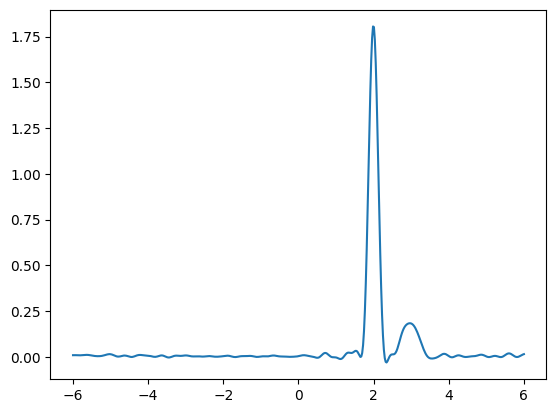

In [107]:
x_dist,xaxis = shors.position_plotting(rho_qumode_0,cutoff)
display(plt.plot(xaxis,x_dist))

1.1196379968461614


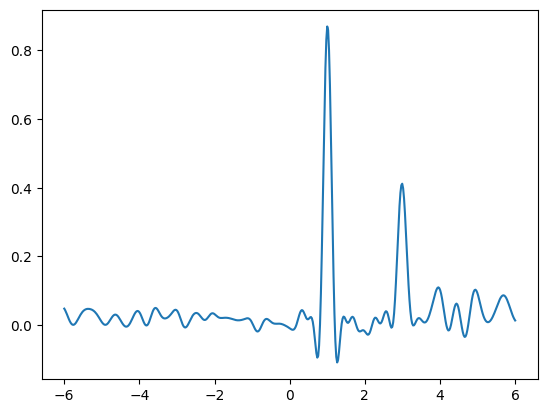

In [108]:
x_dist,xaxis = shors.position_plotting(rho_qumode_1,cutoff)
display(plt.plot(xaxis,x_dist))

0.6358987606029438


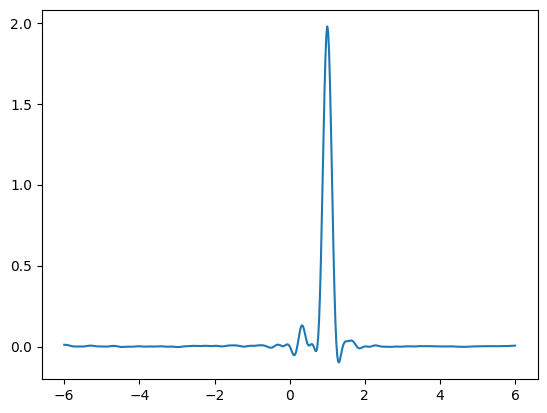

In [109]:
x_dist,xaxis = shors.position_plotting(rho_qumode_2,cutoff)
display(plt.plot(xaxis,x_dist))

## Uanm Gate

In [ ]:
circuit = c2qa.CVCircuit(qmr1,qbr,cr)
circuit.cv_sq(-np.log(0.202),qmr1[0])  # qumode 0 in squeezed vaccum at x=0
circuit.cv_sq(-np.log(0.202),qmr1[1])  # qumode 1 in squeezed vaccum at x=0
circuit.cv_sq(-np.log(0.202),qmr1[2])  # qumode 2 in squeezed vaccum at x=0

Q_displace = shors.Q_displacement_plus1(cutoff)
gate1 =UnitaryGate(Q_displace.full(), label='Q+1')

circuit.append(gate1, qmr1[0])  # qumode 0 in squeezed vaccum at x=1
circuit.append(gate1, qmr1[0])  # qumode 0 in squeezed vaccum at x=2
# circuit.append(gate1, qmr1[0])  # qumode 0 in squeezed vaccum at x=3

circuit.append(gate1, qmr1[1])  # qumode 1 in squeezed vaccum at x=1
# circuit.append(gate1, qmr1[1])  # qumode 1 in squeezed vaccum at x=2
# circuit.append(gate1, qmr1[1])  # qumode 1 in squeezed vaccum at x=3
# circuit.append(gate1, qmr1[1])  # qumode 1 in squeezed vaccum at x=4


circuit.append(gate1, qmr1[2])  # qumode 2 in squeezed vaccum at x=1

circuit.barrier()

circuit = shors.U_aNm(cutoff,circuit,qmr1,qbr,3,6,2)

circuit.measure(qbr[0],cr)

stateop, result, _ = c2qa.util.simulate(circuit,shots = 128)


3
3
V gates done


In [111]:
rho_qumode_2 = shors.get_reduced_qumode_density_matrix(stateop, qumode_index=2, num_qumodes=3, cutoff=cutoff)
rho_qumode_1 = shors.get_reduced_qumode_density_matrix(stateop, qumode_index=1, num_qumodes=3, cutoff=cutoff)
rho_qumode_0 = shors.get_reduced_qumode_density_matrix(stateop, qumode_index=0, num_qumodes=3, cutoff=cutoff)

2.0035731231250384


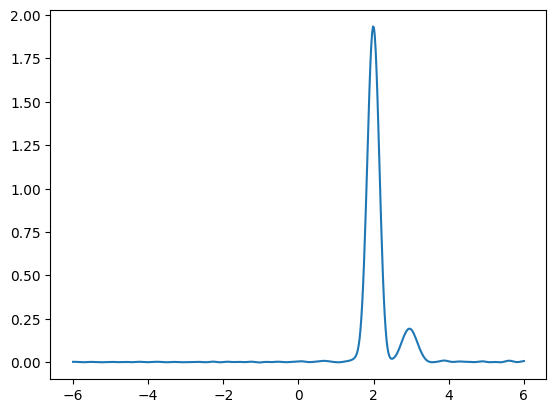

In [112]:
x_dist,xaxis = shors.position_plotting(rho_qumode_0,cutoff)
display(plt.plot(xaxis,x_dist))

2.2932435721533833


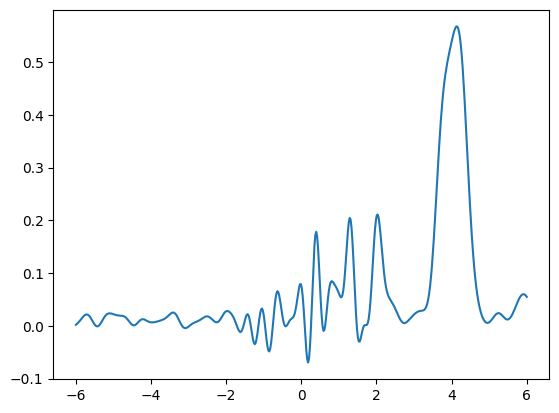

In [113]:
x_dist,xaxis = shors.position_plotting(rho_qumode_1,cutoff)
display(plt.plot(xaxis,x_dist))

0.9259667210970827


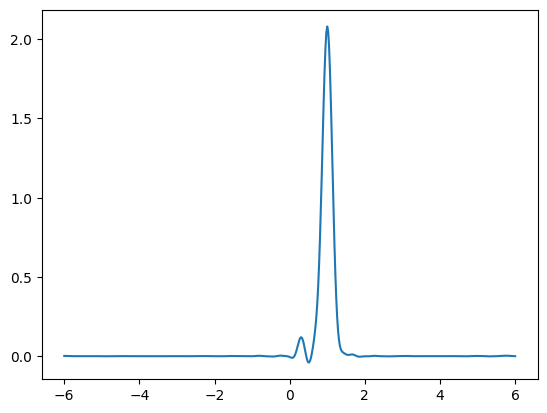

In [114]:
x_dist,xaxis = shors.position_plotting(rho_qumode_2,cutoff)
display(plt.plot(xaxis,x_dist))